 ## preparation of the decomposed automaton

In [ ]:
# generate n chains of length m, where n and m are given by the user, default n = 5, m = 10
# fix some order of the chains
# add dependencies on the edges such that the edge of one chain depends on the states of later chains (not the previous ones in the fixed order)
# the number of states on which a given edge depends is chosen uniformly from {0,1, 2, 3}..if there are multiple states, they need to be from different chains.

import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import random

def gen_chains(n=5, m=10):
    chains = defaultdict(list)

    for i in range(n):
        G = nx.Graph()
        nodes = [j for j in range(m)]
        edges = list(zip(nodes[:-1], nodes[1:]))

        G.add_edges_from(edges)
        chains[i] = G

    return chains

def add_enabling(chains):
    n = len(chains)
    
    for chain_id in range(n-1):
        G = chains[chain_id]
        
        for edge in G.edges():
            if random.random() < 0.5:
                num_deps = random.randint(0, 3)
                
                if num_deps > 0:
                    later_chains = list(range(chain_id + 1, n))
                    selected_chains = random.sample(later_chains, min(num_deps, len(later_chains)))
                    
                    enabling_conditions = []
                    for enabling_chain in selected_chains:
                        enabling_G = chains[enabling_chain]
                        enabling_node = random.choice(list(enabling_G.nodes()))
                        enabling_conditions.append({'automata_id':enabling_chain,'node_id':enabling_node})
                    
                    G.edges[edge]['enabling'] = enabling_conditions
    
    return chains

chains = add_enabling(gen_chains())

In [ ]:
print(chains[0].edges[(1,2)])

In [ ]:
for chain_id in range(len(chains)):
    print(f"\nChain {chain_id}:")
    G = chains[chain_id]
    for edge in G.edges(data=True):
        print(f"Edge {edge[0]} -> {edge[1]}: {edge[2]}")

In [ ]:
chains[0].nodes

## creation of 1 sample problem

In [ ]:
# for the fixed order of chains, create a vector of states for each chain. states in different chains are chosen randomly.
# choose 1 chain as the target chain
# choose a random target state in the target chain
# the result is sample = {"input": vector of states, "target": target state, "target chain": target chain}

In [ ]:
from itertools import product
def get_vectors(chains):
    states_per_chain = []
    for chain_id in range(len(chains)):
        states_per_chain.append(list(chains[chain_id].nodes()))
    
    return list(product(*states_per_chain))

vecs = get_vectors(chains)

In [ ]:
from tqdm import tqdm
id_2_vec = {}
vec_2_id = {}
for i, comb in tqdm(enumerate(vecs)):
    id_2_vec[i] = comb
    vec_2_id[comb] = i

In [ ]:
def get_sample(vector, chains):
    num_chains = len(chains)
    num_states = len(chains[0].nodes())
    
    target_chain = random.randint(0, num_chains-1)

    target_state = random.randint(0, num_states-1)
    
    return {
        'input': list(vector),
        'target_state': target_state,
        'target_chain': target_chain
    }

In [ ]:
sample = get_sample(vecs[12223], chains)
sample

## implementation of the solver

In [ ]:
sample = {'input': [1, 2, 2, 2, 3], 'target_state': 7, 'target_chain': 0}

In [ ]:
def get_rule(chains, target_chain, cur_node, next_node):
    return chains[target_chain].get_edge_data(cur_node, next_node)

def get_shortest_path(chains, target_chain, current_state, target_state):
    return nx.shortest_path(chains[target_chain],current_state[target_chain], target_state)

def solve(sample, chains, path=[]):
    target_chain = sample["target_chain"]
    target_state = sample["target_state"]
    current_state = list(sample["input"])
    shortest_paths = get_shortest_path(chains, target_chain, current_state, target_state)
    for i, cur_node in enumerate(shortest_paths):
        if i < len(shortest_paths)-1:
            next_node = shortest_paths[i+1]
            cur_rule = get_rule(chains, target_chain, cur_node, next_node)
            if cur_rule == {}:
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node
                continue
            else:
                for rules in cur_rule["enabling"]:
                    new_sample = {}
                    new_sample['input'] = current_state
                    new_sample["target_state"] = rules["node_id"]
                    new_sample['target_chain'] = rules["automata_id"]
                    path, current_state = solve(new_sample, chains, path)
                path.append({"automata_id": target_chain, "state_change": (cur_node,next_node)})
                current_state[target_chain] = next_node
                # after each dependency state is resolved, cross the edge and append it to the path and change the current state
                # after the shortest path to the target state if traversed, return the path and the current state
    return path, current_state
            
    # for the target chain, find all shortest paths from the current state to the target state
    # take the first path and try to traverse it. ie iterate over the edges and do the following:
    # # if the edge is not dependent on other states:
    # # # cross the edge, i.e. change the current state for the target chain to get one more step closer to the target state
    # # # path.append(edge)
    # # else get the dependency states, depenendet = edge['enabling']
    # # for each dependency state, do the following:
    # # # new_sample = {}
    # # # new_sample['input_states'] = current_state
    # # # new_sample["target"] = dependency_state
    # # # new_sample['target chain'] = chain of the dependency state
    # # # path, current_state = solve(new_sample,path)
    # # after each dependency state is resolved, cross the edge and append it to the path and change the current state
    # after the shortest path to the target state if traversed, return the path and the current state

In [40]:
path = solve(sample, chains)
path

([{'automata_id': 0, 'state_change': (1, 2)},
  {'automata_id': 0, 'state_change': (2, 3)},
  {'automata_id': 1, 'state_change': (2, 3)},
  {'automata_id': 4, 'state_change': (3, 4)},
  {'automata_id': 4, 'state_change': (4, 5)},
  {'automata_id': 4, 'state_change': (5, 6)},
  {'automata_id': 3, 'state_change': (2, 1)},
  {'automata_id': 2, 'state_change': (2, 1)},
  {'automata_id': 3, 'state_change': (1, 2)},
  {'automata_id': 4, 'state_change': (6, 5)},
  {'automata_id': 4, 'state_change': (5, 4)},
  {'automata_id': 4, 'state_change': (4, 3)},
  {'automata_id': 4, 'state_change': (3, 2)},
  {'automata_id': 3, 'state_change': (2, 3)},
  {'automata_id': 3, 'state_change': (3, 4)},
  {'automata_id': 3, 'state_change': (4, 5)},
  {'automata_id': 3, 'state_change': (5, 6)},
  {'automata_id': 1, 'state_change': (3, 4)},
  {'automata_id': 4, 'state_change': (2, 3)},
  {'automata_id': 4, 'state_change': (3, 4)},
  {'automata_id': 4, 'state_change': (4, 5)},
  {'automata_id': 4, 'state_change

In [ ]:
def group_automata(data):
    changes, finals = data
    result = []
    
    for change in changes:
        if result and result[-1]['automata_id'] == change['automata_id']:
            result[-1]['state_change'].append(change['state_change'])
        else:
            result.append({'automata_id': change['automata_id'], 
                         'state_change': [change['state_change']]})
            
    return (result, finals)

In [ ]:
path_grp = group_automata(path)
path_grp

**Prepare data for visualization**

In [ ]:
shortest_paths = {}

for step in path[0]:
    shortest_paths[step['automata_id']] = nx.shortest_path(chains[step['automata_id']],
                                                           step['state_change'][1], )
    print(step)

**Visualization**

308
{'automata_id': 0, 'state_change': (1, 2)}
{'automata_id': 0, 'state_change': (1, 2)}


/home/jan/miniconda3/envs/sos/lib/python3.11/site-packages/networkx/drawing/nx_pylab.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


{'automata_id': 0, 'state_change': (2, 3)}
{'automata_id': 1, 'state_change': (2, 3)}
{'automata_id': 4, 'state_change': (3, 4)}
{'automata_id': 4, 'state_change': (4, 5)}
{'automata_id': 4, 'state_change': (5, 6)}
{'automata_id': 3, 'state_change': (2, 1)}
{'automata_id': 2, 'state_change': (2, 1)}
{'automata_id': 3, 'state_change': (1, 2)}
{'automata_id': 4, 'state_change': (6, 5)}
{'automata_id': 4, 'state_change': (5, 4)}
{'automata_id': 4, 'state_change': (4, 3)}
{'automata_id': 4, 'state_change': (3, 2)}
{'automata_id': 3, 'state_change': (2, 3)}
{'automata_id': 3, 'state_change': (3, 4)}
{'automata_id': 3, 'state_change': (4, 5)}
{'automata_id': 3, 'state_change': (5, 6)}
{'automata_id': 1, 'state_change': (3, 4)}
{'automata_id': 4, 'state_change': (2, 3)}
{'automata_id': 4, 'state_change': (3, 4)}
{'automata_id': 4, 'state_change': (4, 5)}
{'automata_id': 4, 'state_change': (5, 6)}
{'automata_id': 4, 'state_change': (6, 7)}
{'automata_id': 4, 'state_change': (7, 8)}
{'automata_

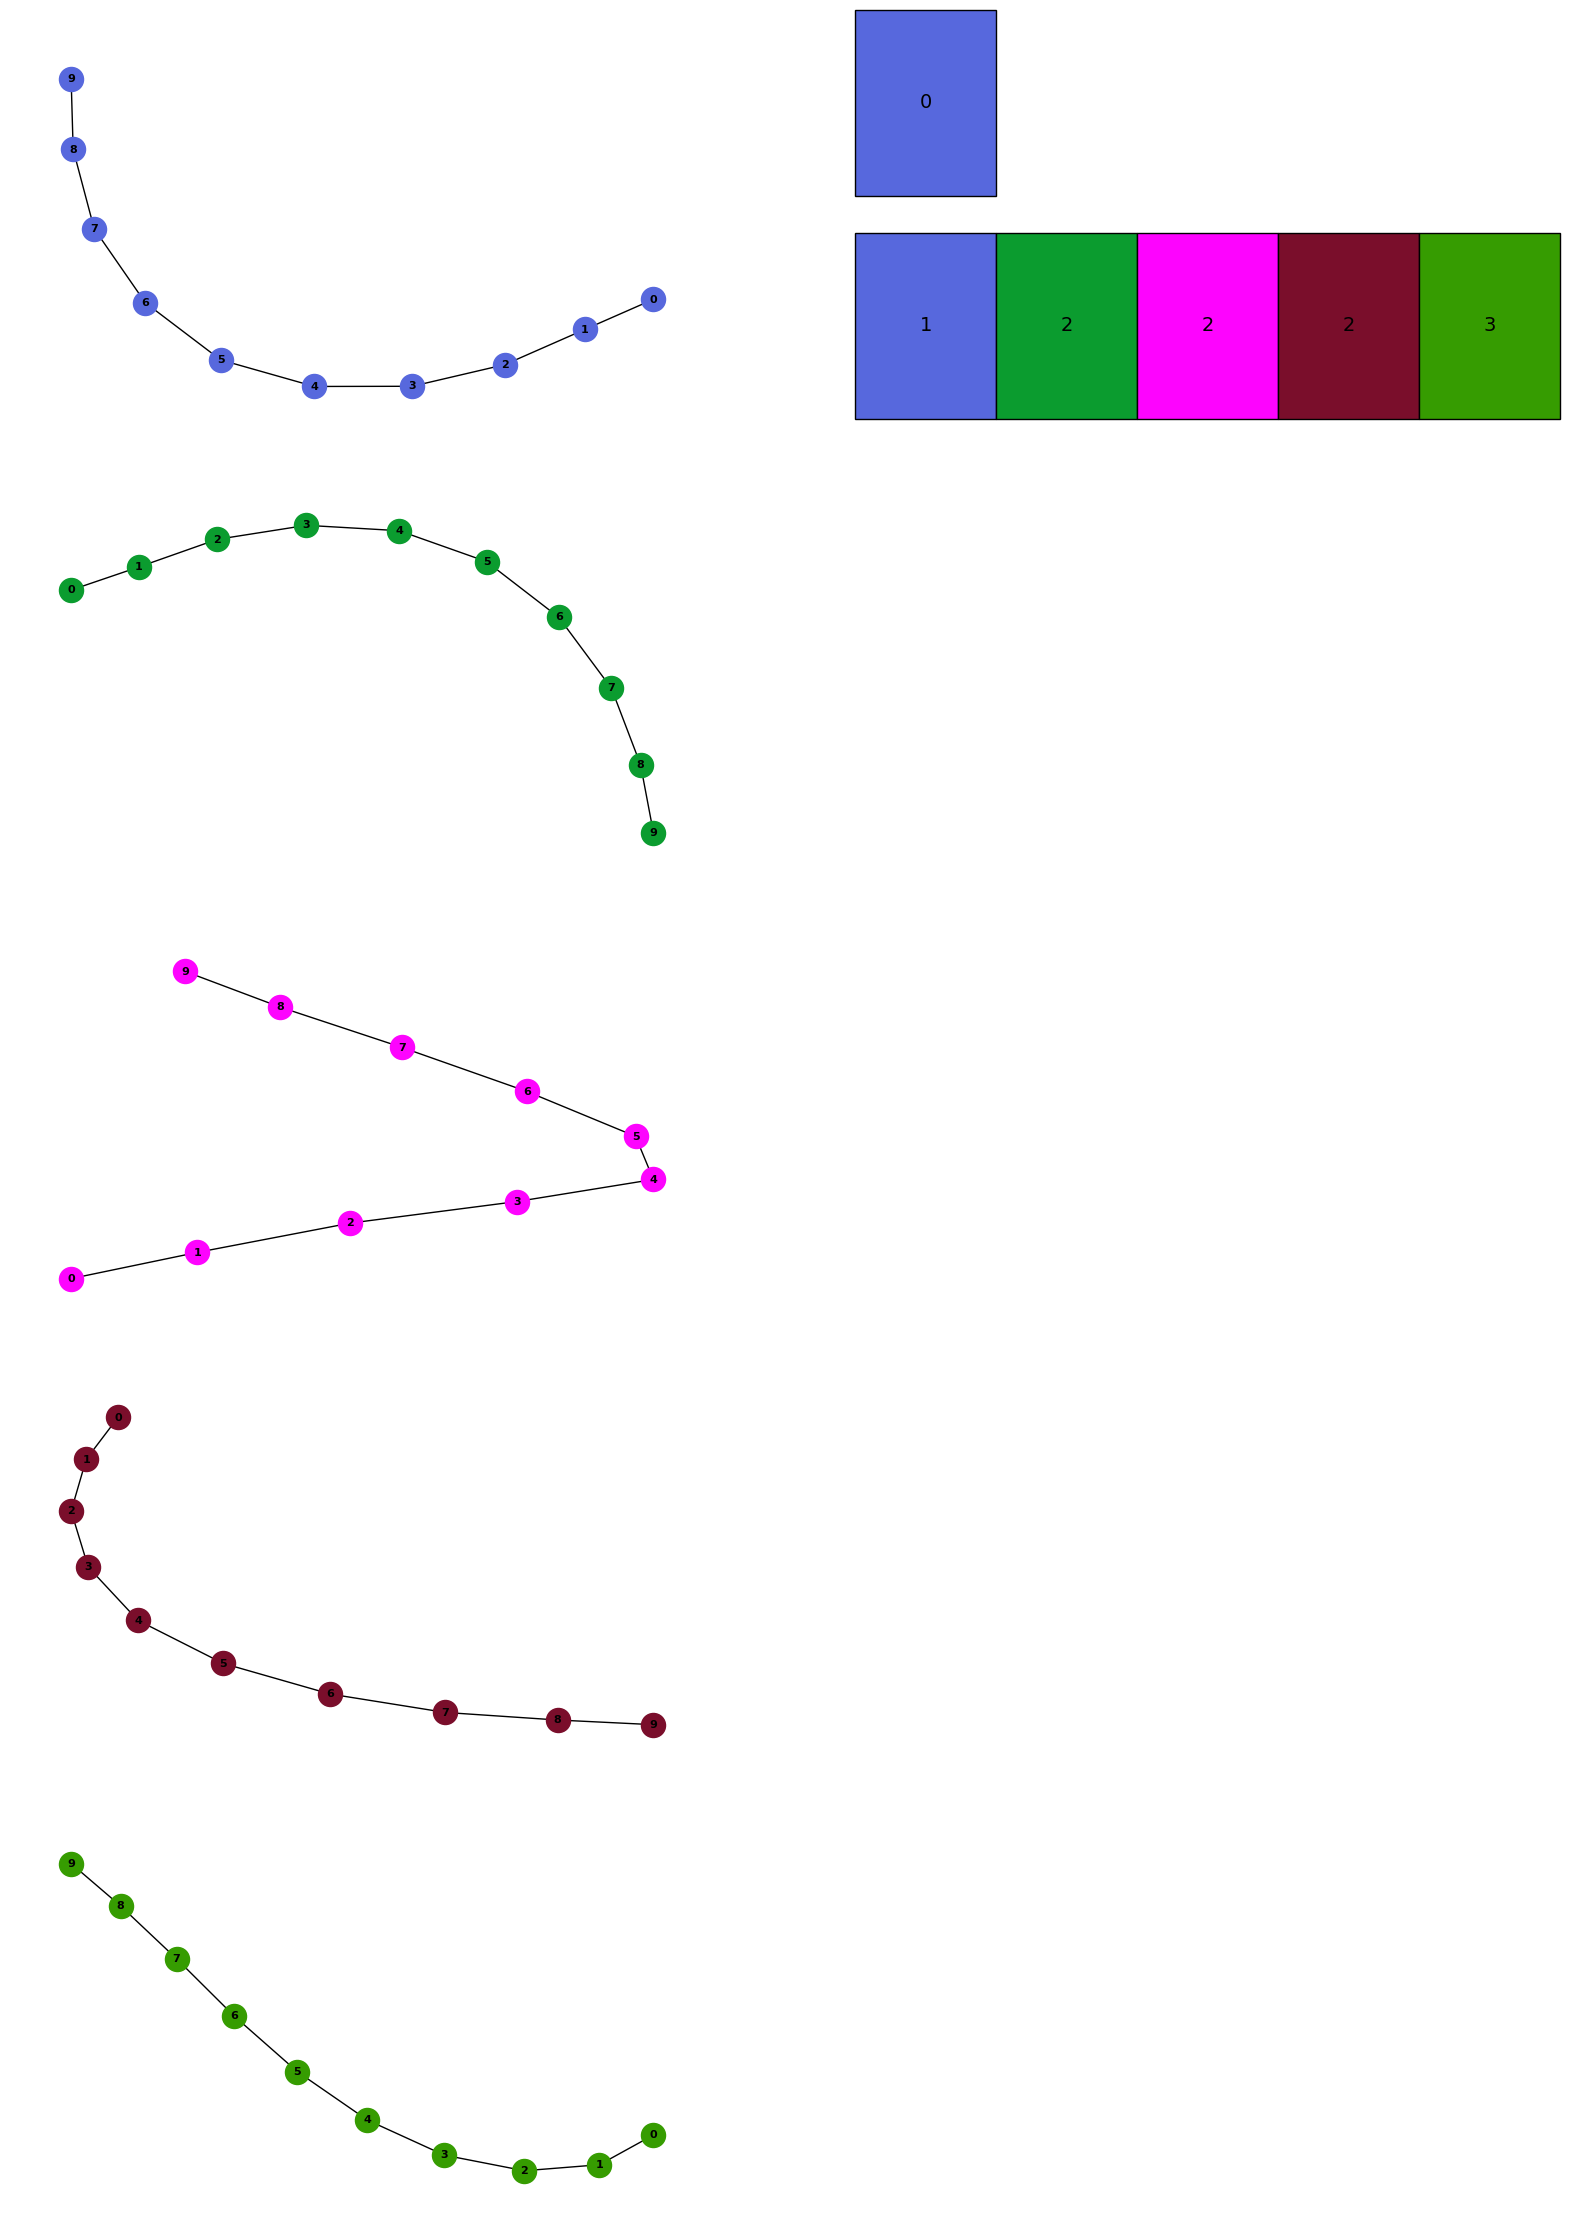

In [43]:
import visualize_search as vs
import importlib

importlib.reload(vs)


visualization = vs.Visualize_search(chains, path[0], sample['input'])
visualization.animate("test_visualization")